# Reconstrução de Séries Temporais de Imagens Sentinel-2: Métodos de Mediana

Este notebook implementa um pipeline completo, profissional e reprodutível para
processamento, filtragem e reconstrução de séries temporais de imagens de satélite do
Sentinel-2 (refletância de superfície, BOA - Bottom of Atmosphere). A área de estudo
compreende o Reservatório de Gramame (Paraíba, Brasil) durante o ano de 2020.

**Stack multibanda**: cada arquivo `.tif` bruto possui 6 bandas espectrais na ordem
`[blue, green, red, nir, swir1, swir2]`. Todo o pipeline opera sobre arrays 4D
`(tempo, bandas, altura, largura)`, processando cada canal espectral de forma
matematicamente independente — sem mistura de bandas em nenhuma etapa.

## Contexto Científico e Metodologia

A pipeline de dados geospaciais executa as seguintes etapas:

1. **Ingestão e Filtragem de Ruído (ETL):** Alinhamento espacial das bandas de satélite
   e das máscaras de cena. Nuvens e sombras são filtradas e representadas como `NaN`.
2. **Método 1 — Composta de Mediana Anual (Composite):** Geração de uma imagem
   representativa única com o valor típico (mediana temporal) de cada pixel ao longo do
   ano, por banda.
3. **Método 2 — Reconstrução por Mediana Móvel Temporal (Global):** Filtro de mediana
   móvel com janela deslizante centrada em T=5, aplicado banda a banda.
4. **Método 3 — Reconstrução por Mediana Móvel Local:** Imputação cirúrgica apenas nos
   pixels com NaN, preservando 100% dos dados limpos originais (RMSE = 0), por banda.
5. **Validação Numérica Controlada (SSIM / PSNR):** Degradação sintética controlada
   para avaliar quantitativamente a qualidade da reconstrução por banda espectral.

## Sumário
1. [Setup do Ambiente e Configurações](#1.-Setup-do-Ambiente-e-Configurações)
2. [Definição de Funções e Módulos](#2.-Definição-de-Funções-e-Módulos)
3. [Ingestão e Preparação de Dados (ETL)](#3.-Ingestão-e-Preparação-de-Dados-(ETL))
4. [Diagnóstico de Qualidade da Série Temporal](#4.-Diagnóstico-de-Qualidade-da-Série-Temporal)
5. [Execução e Salvamento dos Métodos de Reconstrução](#5.-Execução-e-Salvamento-dos-Métodos-de-Reconstrução)
6. [Visualizações Comparativas e Análise de Séries Temporais](#6.-Visualizações-Comparativas-e-Análise-de-Séries-Temporais)
7. [Validação Quantitativa com Métricas SSIM e PSNR](#7.-Validação-Quantitativa-com-Métricas-SSIM-e-PSNR)

## 1. Setup do Ambiente e Configurações

Imports e constantes globais do projeto.

In [1]:
# Imports da biblioteca padrão
import datetime
import glob
import os
from pathlib import Path
import re
import warnings

# Imports de terceiros para computação científica, álgebra linear e visualização
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from scipy.ndimage import binary_dilation
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Utilitários de exibição no Jupyter
from IPython.display import Image, display

# Reprodutibilidade e parametrização dos plots
plt.rcParams["figure.dpi"] = 110

In [ ]:
# Raiz do projeto (aponta para a pasta pai de notebooks/)
PROJECT_ROOT = Path("../")

# Definição e organização estrutural de diretórios
RAW_DIR   = PROJECT_ROOT / "data" / "raw" / "imagens"
MASK_DIR  = PROJECT_ROOT / "data" / "raw" / "mascaras"
OUT_COMPOSITE_DIR = PROJECT_ROOT / "outputs" / "median_composite"
OUT_TEMPORAL_DIR  = PROJECT_ROOT / "outputs" / "temporal_reconstruction"
OUT_LOCAL_DIR     = PROJECT_ROOT / "outputs" / "local_reconstruction"
FIGURES_DIR       = PROJECT_ROOT / "figures"

# Criação automática dos diretórios de saída
for directory in [OUT_COMPOSITE_DIR, OUT_TEMPORAL_DIR, OUT_LOCAL_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Padrão de caminhos para carregamento de arquivos .tif
TIF_PATTERN  = str(RAW_DIR  / "*.tif")
MASK_PATTERN = str(MASK_DIR / "*.tif")

# Constante de janela temporal para suavização por mediana móvel (janela centrada)
JANELA_TEMPORAL = 5

# Bandas espectrais dos arquivos Sentinel-2 brutos, na ordem exata dos canais do .tif
# Confirmado empiricamente via rasterio: cada .tif possui 6 bandas nesta sequência.
NOMES_BANDAS = ["blue", "green", "red", "nir", "swir1", "swir2"]

CORES_BANDAS = {
    'blue': '#1f77b4',
    'green': '#2ca02c',
    'red': '#d62728',
    'nir': '#9467bd',
    'swir1': '#8c564b',
    'swir2': '#e377c2'
}

# Índices convenientes para composição RGB
IDX_R = NOMES_BANDAS.index("red")
IDX_G = NOMES_BANDAS.index("green")
IDX_B = NOMES_BANDAS.index("blue")
IDX_NIR = NOMES_BANDAS.index("nir")

print(f"Dados brutos em:              {RAW_DIR}")
print(f"Máscaras em:                  {MASK_DIR}")
print(f"Saída Composite:              {OUT_COMPOSITE_DIR}")
print(f"Saída Reconstrução Temporal:  {OUT_TEMPORAL_DIR}")
print(f"Saída Reconstrução Local:     {OUT_LOCAL_DIR}")
print(f"Bandas espectrais:            {NOMES_BANDAS}")

Dados brutos em:              ../data/raw/imagens
Máscaras em:                  ../data/raw/mascaras
Saída Composite:              ../outputs/median_composite
Saída Reconstrução Temporal:  ../outputs/temporal_reconstruction
Saída Reconstrução Local:     ../outputs/local_reconstruction
Bandas espectrais:            ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']


## 2. Definição de Funções e Módulos

Esta seção contém todas as definições das funções utilizadas no notebook, organizadas em
quatro grupos: (1) utilitários de I/O, (2) ingestão e carregamento, (3) reconstrução
temporal e (4) validação de qualidade.

In [3]:
def extrair_data_do_nome(filepath: "str | Path", pattern: str = r"(\d{4}-?\d{2}-?\d{2})") -> "datetime.datetime | None":
    """Extrai um objeto datetime do nome de um arquivo com base em uma regex.

    Procura por uma data formatada em YYYYMMDD ou YYYY-MM-DD no nome do arquivo.

    Args:
        filepath (str or Path): Caminho absoluto ou relativo do arquivo.
        pattern (str): Regex para identificar a string da data.

    Returns:
        datetime.datetime or None: Data correspondente ou None se não encontrada.
    """
    nome = os.path.basename(filepath)
    match = re.search(pattern, nome)
    if match:
        data_str = match.group(1).replace("-", "")
        try:
            return datetime.datetime.strptime(data_str, "%Y%m%d")
        except ValueError:
            return None
    return None

In [4]:
def salvar_geotiff(array: np.ndarray, profile_referencia: dict, out_path: "str | Path", dtype=rasterio.float32, nodata: float = np.nan) -> None:
    """Salva um array numpy bidimensional no formato GeoTIFF georreferenciado (banda única).

    Args:
        array (np.ndarray): Matriz bidimensional (altura, largura) com os dados de pixel.
        profile_referencia (dict): Perfil com metadados do Rasterio (CRS, Transform, etc).
        out_path (str or Path): Caminho de destino para salvar o arquivo.
        dtype (numpy.dtype or rasterio.dtype): Tipo de dado do raster de saída.
        nodata (float or int): Valor representativo de pixels sem dado (nodata).
    """
    perfil = profile_referencia.copy()
    perfil.update(dtype=dtype, count=1, nodata=nodata)
    with rasterio.open(out_path, "w", **perfil) as dst:
        dst.write(array.astype(dtype), 1)
    print(f"Salvo: {out_path}")


def salvar_geotiff_multibanda(
    array: np.ndarray,
    profile_referencia: dict,
    out_path: "str | Path",
    nomes_bandas: "list[str] | None" = None,
    dtype=rasterio.float32,
    nodata: float = np.nan,
) -> None:
    """Salva um array numpy tridimensional no formato GeoTIFF multibanda georreferenciado.

    Escreve todas as bandas espectrais em um único arquivo .tif, preservando os nomes
    das bandas nos metadados via set_band_description. O formato de saída é compatível
    com o dos arquivos brutos originais do Sentinel-2.

    Args:
        array (np.ndarray): Matriz 3D de shape (bandas, altura, largura).
        profile_referencia (dict): Perfil com metadados do Rasterio (CRS, Transform, etc).
        out_path (str or Path): Caminho de destino para salvar o arquivo.
        nomes_bandas (list of str, optional): Nomes das bandas para os metadados.
            Se None, não adiciona descrições de banda.
        dtype (numpy.dtype or rasterio.dtype): Tipo de dado do raster de saída.
        nodata (float or int): Valor representativo de pixels sem dado (nodata).

    Raises:
        ValueError: Se array não for 3D.
    """
    if array.ndim != 3:
        raise ValueError(
            f"Esperado array 3D (bandas, altura, largura), recebido shape {array.shape}."
        )
    n_bandas = array.shape[0]

    perfil = profile_referencia.copy()
    perfil.update(dtype=dtype, count=n_bandas, nodata=nodata)

    with rasterio.open(out_path, "w", **perfil) as dst:
        for b in range(n_bandas):
            dst.write(array[b].astype(dtype), b + 1)
            if nomes_bandas is not None and b < len(nomes_bandas):
                dst.set_band_description(b + 1, nomes_bandas[b])
    print(f"Salvo: {out_path}")

In [5]:
def carregar_stack_com_mascara(tif_files: "list[str]", mask_files: "list[str]") -> "tuple[np.ndarray, dict, list]":
    """Lê arquivos geospaciais Sentinel-2 e suas máscaras, construindo um stack 4D.

    Garante que todas as imagens possuam as mesmas dimensões espaciais e número de
    bandas. Substitui pixels marcados como nuvem ou sombra por NaN em TODAS as bandas
    simultaneamente (broadcasting espacial), sem recalcular a máscara por canal — uma
    nuvem obstrui toda a cena independente do comprimento de onda.

    A máscara de entrada é um produto binário derivado com legenda própria de 3 classes:
        0 = pixel limpo
        1 = nuvem
        2 = sombra de nuvem

    Args:
        tif_files (list of str): Lista ordenada de caminhos para as imagens geospaciais.
        mask_files (list of str): Lista ordenada de caminhos para as máscaras correspondentes.

    Returns:
        tuple: (stack, profile, datas) contendo:
            - stack (np.ndarray): Matriz 4D de shape (tempo, bandas, altura, largura).
            - profile (dict): Perfil de metadados do Rasterio da imagem inicial.
            - datas (list of datetime.datetime): Lista das datas correspondentes.

    Raises:
        ValueError: Se as dimensões de alguma imagem ou máscara não forem idênticas às
            da imagem de referência (primeira imagem da lista).
        ValueError: Se a máscara contiver valores fora do conjunto esperado {0, 1, 2}.
    """
    with rasterio.open(tif_files[0]) as src:
        profile   = src.profile.copy()
        height    = src.height
        width     = src.width
        n_bandas  = src.count
        nodata_val = src.nodata

    n = len(tif_files)
    stack = np.empty((n, n_bandas, height, width), dtype=np.float32)
    datas = []

    for i, (fp_dado, fp_masc) in enumerate(zip(tif_files, mask_files)):
        with rasterio.open(fp_dado) as src_dado, rasterio.open(fp_masc) as src_masc:

            # Validação de dimensões espaciais
            if (src_dado.height, src_dado.width) != (height, width):
                raise ValueError(
                    f"Imagem {fp_dado} fora do padrão espacial ({height}x{width})."
                )
            if (src_masc.height, src_masc.width) != (height, width):
                raise ValueError(
                    f"Máscara {fp_masc} fora do padrão espacial ({height}x{width})."
                )

            # Lê todas as bandas de uma só vez → shape (n_bandas, altura, largura)
            bands = src_dado.read().astype(np.float32)

            # Nodata handling aplicado a todas as bandas simultaneamente
            if nodata_val is not None:
                bands[bands == nodata_val] = np.nan

            # Máscara de nuvem/sombra: shape 2D (altura, largura)
            band_masc = src_masc.read(1)

            # Validação defensiva: verifica que a máscara contém apenas {0, 1, 2}
            valores_presentes = set(np.unique(band_masc).tolist())
            valores_validos   = {0, 1, 2}
            if not valores_presentes.issubset(valores_validos):
                valores_inesperados = valores_presentes - valores_validos
                raise ValueError(
                    f"Máscara {fp_masc} contém valores inesperados: {valores_inesperados}. "
                    f"Esperado subconjunto de {{0, 1, 2}}."
                )

            # Aplica máscara a TODAS as bandas via broadcasting:
            # condicao_ruido é 2D (H, W); bands[:, condicao_ruido] = NaN afeta as 6 bandas
            condicao_ruido = np.isin(band_masc, [1, 2])
            bands[:, condicao_ruido] = np.nan

            stack[i] = bands

        datas.append(extrair_data_do_nome(fp_dado))

    return stack, profile, datas

In [ ]:
def reconstrucao_mediana_movel(stack: np.ndarray, janela: int) -> np.ndarray:
    """Aplica um filtro de mediana móvel no eixo temporal, ignorando NaNs.

    Trabalha com uma janela deslizante centrada. Se todos os pixels da janela temporal
    forem NaN, o valor de saída permanece NaN. Opera sobre stack 3D (tempo, H, W).

    Args:
        stack (np.ndarray): Matriz 3D de shape (tempo, altura, largura).
        janela (int): O número de observações consecutivas na janela temporal.

    Returns:
        np.ndarray: Série temporal suavizada com a mesma shape do stack original.
    """
    n_datas = stack.shape[0]
    meia_janela = janela // 2
    reconstruido = np.empty_like(stack)

    for t in range(n_datas):
        ini = max(0, t - meia_janela)
        fim = min(n_datas, t + meia_janela + 1)
        janela_dados = stack[ini:fim]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="All-NaN slice encountered")
            reconstruido[t] = np.nanmedian(janela_dados, axis=0)

    return reconstruido


def reconstrucao_mediana_movel_multibanda(stack: np.ndarray, janela: int, nomes_bandas: "list[str] | None" = None) -> np.ndarray:
    """Aplica filtro de mediana móvel global banda a banda sobre stack 4D.

    Reaproveita `reconstrucao_mediana_movel` para cada banda de forma isolada,
    garantindo que a mediana temporal de uma banda (ex: blue) NUNCA seja influenciada
    por valores de outra banda (ex: nir). Cada canal preserva sua própria física de
    reflectância.

    Args:
        stack (np.ndarray): Matriz 4D de shape (tempo, bandas, altura, largura).
        janela (int): O número de observações consecutivas na janela temporal.
        nomes_bandas (list of str, optional): Rótulos das bandas para prints de
            diagnóstico. Se None, usa índices numéricos.

    Returns:
        np.ndarray: Stack 4D reconstruído de mesma shape, com cada banda processada
            de forma independente.

    Raises:
        ValueError: Se `stack` não for 4D.
    """
    if stack.ndim != 4:
        raise ValueError(
            f"Esperado stack 4D (tempo, bandas, altura, largura), recebido shape {stack.shape}."
        )

    n_tempo, n_bandas, altura, largura = stack.shape
    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))

    reconstruido = np.empty_like(stack)

    for b, rotulo in zip(range(n_bandas), rotulos):
        # Fatia 3D isolada para esta banda → (tempo, altura, largura)
        stack_banda = stack[:, b, :, :]
        reconstruido[:, b, :, :] = reconstrucao_mediana_movel(stack_banda, janela)

    return reconstruido


def reconstrucao_mediana_movel_local(stack: np.ndarray, janela: int) -> np.ndarray:
    """Reconstrução cirúrgica por mediana móvel exclusivamente sobre pixels ruidosos (NaN).

    Preserva integralmente as observações originalmente limpas, calculando a mediana
    móvel temporal apenas sobre os pixels que continham NaNs. Opera sobre stack 3D.

    Args:
        stack (np.ndarray): Matriz 3D de shape (tempo, altura, largura).
        janela (int): Tamanho da janela temporal (deve ser ímpar).

    Returns:
        np.ndarray: Série temporal reconstruída localmente sem distorção nos dados
            originais (RMSE = 0 nos pixels limpos).
    """
    n_datas = stack.shape[0]
    meia_janela = janela // 2
    reconstruido = stack.copy()

    for t in range(n_datas):
        mask_nan = np.isnan(stack[t])

        if not np.any(mask_nan):
            continue

        ini = max(0, t - meia_janela)
        fim = min(n_datas, t + meia_janela + 1)
        janela_dados = stack[ini:fim]

        dados_locais = janela_dados[:, mask_nan]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="All-NaN slice encountered")
            medianas_calculadas = np.nanmedian(dados_locais, axis=0)

        reconstruido[t][mask_nan] = medianas_calculadas

    return reconstruido


def reconstrucao_mediana_movel_local_multibanda(stack: np.ndarray, janela: int, nomes_bandas: "list[str] | None" = None) -> np.ndarray:
    """Aplica reconstrução cirúrgica por mediana móvel local, banda a banda, de forma
    totalmente independente entre canais espectrais.

    Reaproveita `reconstrucao_mediana_movel_local` para cada banda isoladamente,
    garantindo que a mediana temporal de uma banda (ex: blue) NUNCA seja calculada
    ou substituída usando valores de outra banda (ex: nir). Cada canal preserva sua
    própria física de reflectância.

    Args:
        stack (np.ndarray): Matriz 4D de shape (tempo, bandas, altura, largura).
        janela (int): Tamanho da janela temporal (deve ser ímpar).
        nomes_bandas (list of str, optional): Rótulos das bandas, na ordem do eixo 1
            (ex: ["blue", "green", "red", "nir", "swir1", "swir2"]). Usado apenas
            para os prints de diagnóstico; se omitido, usa índices numéricos.

    Returns:
        np.ndarray: Stack 4D reconstruído de mesma shape, com cada banda processada
            de forma independente.

    Raises:
        ValueError: Se `stack` não for 4D.
        ValueError: Se `nomes_bandas` não bater com o número de bandas presentes.
    """
    if stack.ndim != 4:
        raise ValueError(
            f"Esperado stack 4D (tempo, bandas, altura, largura), recebido shape {stack.shape}. "
            "Se seu stack ainda for 3D (monobanda), use reconstrucao_mediana_movel_local diretamente."
        )

    n_tempo, n_bandas, altura, largura = stack.shape

    if nomes_bandas is not None and len(nomes_bandas) != n_bandas:
        raise ValueError(
            f"nomes_bandas tem {len(nomes_bandas)} elementos, mas o stack possui {n_bandas} banda(s)."
        )
    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))

    reconstruido = np.empty_like(stack)

    for b, rotulo in zip(range(n_bandas), rotulos):
        # Fatia 3D (tempo, altura, largura) desta banda — isolada das demais
        stack_banda = stack[:, b, :, :]
        reconstruido[:, b, :, :] = reconstrucao_mediana_movel_local(stack_banda, janela)

        pct_nan_antes  = 100 * np.isnan(stack_banda).mean()
        pct_nan_depois = 100 * np.isnan(reconstruido[:, b, :, :]).mean()
        print(f"  Banda '{rotulo}': NaN antes = {pct_nan_antes:.2f}% | residual = {pct_nan_depois:.2f}%")

    return reconstruido

In [7]:
def reconstruir_unica_data_multibanda(
    stack: np.ndarray,
    idx: int,
    janela: int,
    img_override: "np.ndarray | None" = None,
    nomes_bandas: "list[str] | None" = None,
) -> np.ndarray:
    """Reconstrói uma única data via mediana móvel local, processando apenas a janela
    temporal ao redor de `idx` — evita reconstruir as demais datas do stack, que não
    são necessárias para validação pontual ou curvas de degradação iterativas.

    Args:
        stack (np.ndarray): Stack 4D original (tempo, bandas, altura, largura).
        idx (int): Índice temporal da imagem a reconstruir.
        janela (int): Tamanho da janela temporal (mesmo usado no pipeline principal).
        img_override (np.ndarray, optional): Se fornecido, shape (bandas, altura, largura),
            substitui stack[idx] antes da reconstrução — usado para injetar corrupção
            sintética sem copiar o stack inteiro.
        nomes_bandas (list of str, optional): Rótulos para diagnóstico; se None, usa índices.

    Returns:
        np.ndarray: Imagem reconstruída, shape (bandas, altura, largura), apenas para `idx`.
    """
    n_tempo, n_bandas, altura, largura = stack.shape
    meia_janela = janela // 2
    ini = max(0, idx - meia_janela)
    fim = min(n_tempo, idx + meia_janela + 1)
    pos = idx - ini

    # Cópia PEQUENA: só a janela temporal (ex: 5 datas), não o stack inteiro (73 datas)
    janela_stack = stack[ini:fim].copy()
    if img_override is not None:
        janela_stack[pos] = img_override

    img_out = janela_stack[pos].copy()
    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))

    for b, rotulo in zip(range(n_bandas), rotulos):
        banda_out = img_out[b]
        mask_nan = np.isnan(banda_out)
        if not np.any(mask_nan):
            continue
        dados_locais = janela_stack[:, b][:, mask_nan]
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="All-NaN slice encountered")
            medianas = np.nanmedian(dados_locais, axis=0)
        banda_out[mask_nan] = medianas

    return img_out

In [8]:
def recompor_composta_pontual_multibanda(
    stack: np.ndarray,
    idx: int,
    mascara_sint: np.ndarray,
    composta_original: np.ndarray,
    nomes_bandas: "list[str] | None" = None,
) -> np.ndarray:
    """Recalcula a composta de mediana anual, sem vazamento de dado, apenas nos pixels
    afetados por uma corrupção sintética injetada na data `idx`.

    A composta original (`composta_original`, já calculada uma vez na Seção 5 usando
    todo o stack limpo) é reaproveitada para todos os pixels FORA da máscara — como
    np.nanmedian é calculado independentemente por pixel ao longo do eixo temporal,
    alterar a data `idx` num pixel não afeta a mediana de nenhum outro pixel. Só os
    pixels DENTRO da máscara sintética têm sua série temporal recalculada, com a data
    `idx` marcada como NaN nesse recálculo — simulando corretamente "como seria a
    composta se essa data estivesse nublada ali", sem usar o valor verdadeiro escondido.

    Args:
        stack (np.ndarray): Stack 4D original (tempo, bandas, altura, largura).
        idx (int): Índice temporal da data corrompida sinteticamente.
        mascara_sint (np.ndarray): Máscara booleana 2D (altura, largura) dos pixels
            corrompidos.
        composta_original (np.ndarray): Composta de mediana anual já calculada sobre o
            stack limpo, shape (bandas, altura, largura) — variável `median_composite`
            da Seção 5.
        nomes_bandas (list of str, optional): Rótulos das bandas.

    Returns:
        np.ndarray: Composta recalculada, shape (bandas, altura, largura), idêntica à
            original fora da máscara e recomputada sem vazamento dentro dela.
    """
    n_tempo, n_bandas, altura, largura = stack.shape
    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))
    composta = composta_original.copy()

    for b, rotulo in zip(range(n_bandas), rotulos):
        # Extrai só a série temporal dos pixels mascarados — muito mais barato que
        # recalcular a composta inteira (73 datas × imagem completa) a cada chamada
        serie_temporal = stack[:, b][:, mascara_sint].copy()
        serie_temporal[idx] = np.nan  # injeta a corrupção sintética na data idx

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message="All-NaN slice encountered")
            medianas_recalculadas = np.nanmedian(serie_temporal, axis=0)

        composta[b][mascara_sint] = medianas_recalculadas

    return composta

In [9]:
def reconstruir_unica_data_global_multibanda(
    stack: np.ndarray,
    idx: int,
    janela: int,
    img_override: "np.ndarray | None" = None,
    nomes_bandas: "list[str] | None" = None,
) -> np.ndarray:
    """Reconstrói uma única data via mediana móvel GLOBAL (Método 2), processando apenas
    a janela temporal ao redor de `idx` — evita reconstruir as demais datas do stack.

    Diferente do Método 3 (reconstruir_unica_data_multibanda), este substitui TODOS os
    pixels pela mediana da janela — inclusive os que já eram válidos — pois é assim que
    o Método 2 se comporta no pipeline original (suaviza a série inteira, ao custo de
    leve atenuação em dados originalmente limpos).

    Args:
        stack (np.ndarray): Stack 4D original (tempo, bandas, altura, largura).
        idx (int): Índice temporal da imagem a reconstruir.
        janela (int): Tamanho da janela temporal (mesmo usado no pipeline principal).
        img_override (np.ndarray, optional): Se fornecido, shape (bandas, altura, largura),
            substitui stack[idx] antes da reconstrução — usado para injetar corrupção
            sintética sem copiar o stack inteiro.
        nomes_bandas (list of str, optional): Rótulos para diagnóstico.

    Returns:
        np.ndarray: Imagem reconstruída, shape (bandas, altura, largura), apenas para `idx`.
    """
    n_tempo, n_bandas, altura, largura = stack.shape
    meia_janela = janela // 2
    ini = max(0, idx - meia_janela)
    fim = min(n_tempo, idx + meia_janela + 1)
    pos = idx - ini

    janela_stack = stack[ini:fim].copy()  # cópia pequena: só a janela (ex: 5 datas)
    if img_override is not None:
        janela_stack[pos] = img_override

    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))
    img_out = np.empty((n_bandas, altura, largura), dtype=np.float32)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="All-NaN slice encountered")
        for b, rotulo in zip(range(n_bandas), rotulos):
            img_out[b] = np.nanmedian(janela_stack[:, b], axis=0)

    return img_out

In [ ]:
def gerar_mascara_nuvem_sintetica(
    shape: "tuple[int, int]",
    taxa_corrupcao: float,
    seed: int,
    n_sementes: int = 5,
) -> np.ndarray:
    """Gera máscara sintética 2D em blob conexo, fisicamente representativa de nuvem real.

    Nuvens reais são regiões espacialmente contíguas, não pixels isolados espalhados
    aleatoriamente (padrão 'sal e pimenta'). A abordagem de blob é essencial para uma
    validação representativa do fenômeno que os métodos de reconstrução foram projetados
    para resolver: `structural_similarity` opera com janelas locais (ex: 11×11), e
    pixels dispersos isolados produzem SSIM trivialmente alto (janela compara
    zeros-com-zeros nas bordas), inflando artificialmente a métrica.

    Algoritmo:
        1. Amostra `n_sementes` pontos-semente aleatórios dentro da grade.
        2. Aplica dilatação morfológica iterativa com estrutura de vizinhança 3×3 até
           que a fração de pixels True atinja ou supere `taxa_corrupcao`.
        3. Trunca o excedente aleatoriamente para bater exatamente com a taxa alvo.

    Args:
        shape (tuple[int, int]): Dimensões (altura, largura) da máscara.
        taxa_corrupcao (float): Fração alvo de pixels True na máscara (ex: 0.15 = 15%).
        seed (int): Semente para reprodutibilidade total.
        n_sementes (int): Número de pontos-semente para iniciar a dilatação.

    Returns:
        np.ndarray: Array booleano 2D de shape `shape`.
    """
    rng = np.random.default_rng(seed)
    altura, largura = shape
    n_total = altura * largura
    n_alvo = int(taxa_corrupcao * n_total)

    mascara = np.zeros((altura, largura), dtype=bool)

    # Sementes iniciais aleatórias
    rows = rng.integers(0, altura, size=n_sementes)
    cols = rng.integers(0, largura, size=n_sementes)
    mascara[rows, cols] = True

    # Estrutura de vizinhança 3×3 para dilatação
    struct = np.ones((3, 3), dtype=bool)

    # Dilata iterativamente até atingir a taxa alvo
    while mascara.sum() < n_alvo:
        mascara = binary_dilation(mascara, structure=struct)
        if mascara.sum() >= n_alvo:
            break

    # Trunca excedente aleatoriamente para bater exatamente na taxa alvo
    indices_true = np.argwhere(mascara)
    if len(indices_true) > n_alvo:
        excedente = len(indices_true) - n_alvo
        idx_remover = rng.choice(len(indices_true), size=excedente, replace=False)
        for idx in idx_remover:
            r, c = indices_true[idx]
            mascara[r, c] = False

    return mascara


In [ ]:
def calcular_metricas_multibanda(ref: np.ndarray, teste: np.ndarray, nomes_bandas: "list[str] | None" = None, data_range_fixo: "float | dict | None" = None) -> dict:
    """Calcula SSIM e PSNR entre imagem de referência e imagem de teste, por banda espectral.

    Suporta rasters monobanda (2D) ou multibanda (3D: bandas, H, W), com tratamento
    robusto de NaN. Pixels NaN em qualquer uma das imagens são excluídos da avaliação.

    Args:
        ref (np.ndarray): Imagem de referência (ground truth), shape (H, W) ou (B, H, W).
        teste (np.ndarray): Imagem sob avaliação, mesmo shape que `ref`.
        nomes_bandas (list of str, optional): Rótulos para cada banda espectral.
            Se None, usa índices numéricos (0, 1, 2, ...).
        data_range_fixo (float, optional): Se fornecido, usa essa amplitude fixa para
            TODAS as bandas. Útil para manter comparabilidade entre múltiplas execuções
            (ex: curvas de degradação), evitando saltos artificiais no PSNR.

    Parâmetros SSIM utilizados (Wang et al., 2004):
        gaussian_weights=True, sigma=1.5, use_sample_covariance=False, win_size=11
        (reduzido automaticamente se a dimensão mínima foi < 11).

    Returns:
        dict: Dicionário com as chaves:
            - "ssim_medio" (float): Média do SSIM entre todas as bandas avaliadas.
            - "psnr_medio" (float): Média do PSNR entre todas as bandas avaliadas.
            - "detalhes_por_banda" (dict): Mapa {rotulo_banda -> {"ssim", "psnr",
              "n_pixels_avaliados"}} com métricas individuais de cada canal espectral.

    Raises:
        ValueError: Se ref e teste tiverem shapes incompatíveis.
        ValueError: Se nomes_bandas não bater com o número de bandas da imagem.
    """
    if ref.shape != teste.shape:
        raise ValueError(
            f"Shapes incompatíveis entre referência {ref.shape} e teste {teste.shape}."
        )

    # Normaliza para 3D: (bandas, H, W)
    entrada_era_2d = ref.ndim == 2
    ref_3d   = ref[np.newaxis, ...]   if entrada_era_2d else ref
    teste_3d = teste[np.newaxis, ...] if entrada_era_2d else teste

    n_bandas = ref_3d.shape[0]

    # Define os rótulos de forma segura
    if nomes_bandas is not None:
        if len(nomes_bandas) != n_bandas:
            raise ValueError(f"O número de nomes_bandas ({len(nomes_bandas)}) não confere com o número de bandas ({n_bandas}).")
        rotulos = nomes_bandas
    else:
        rotulos = list(range(n_bandas))

    detalhes_por_banda = {}
    ssim_values = []
    psnr_values = []
    nrmse_values = []

    for b, rotulo in zip(range(n_bandas), rotulos):
        banda_ref   = ref_3d[b]
        banda_teste = teste_3d[b]

        mask_valida        = ~np.isnan(banda_ref) & ~np.isnan(banda_teste)
        n_pixels_avaliados = int(mask_valida.sum())

        if n_pixels_avaliados == 0:
            detalhes_por_banda[rotulo] = {
                "ssim": np.nan,
                "psnr": np.nan,
                "n_pixels_avaliados": 0,
            }
            continue

        valid_ref   = banda_ref[mask_valida]
        valid_teste = banda_teste[mask_valida]

        if data_range_fixo is not None:
            if isinstance(data_range_fixo, dict):
                data_range = float(data_range_fixo[rotulo])
            else:
                data_range = float(data_range_fixo)
        else:
            data_range = float(
                max(valid_ref.max(), valid_teste.max())
                - min(valid_ref.min(), valid_teste.min())
            )
            if data_range == 0:
                data_range = 1.0

        psnr_val = peak_signal_noise_ratio(valid_ref, valid_teste, data_range=data_range)

        # NRMSE: erro absoluto normalizado pela amplitude física da própria banda,
        # expresso em %. Ao contrário do PSNR (escala log, sensível ao tamanho do
        # data_range), o NRMSE é diretamente comparável entre bandas de escalas
        # diferentes — "3% de erro" significa a mesma coisa em blue e em NIR.
        rmse_val = float(np.sqrt(np.mean((valid_ref - valid_teste) ** 2)))
        nrmse_pct = 100 * rmse_val / data_range
        # Matrizes 2D sem NaN para o cálculo espacial do SSIM (zeros nas regiões inválidas)
        banda_ref_ssim   = np.zeros_like(banda_ref,   dtype=np.float32)
        banda_teste_ssim = np.zeros_like(banda_teste, dtype=np.float32)
        banda_ref_ssim[mask_valida]   = valid_ref
        banda_teste_ssim[mask_valida] = valid_teste

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # Parâmetros explícitos conforme Wang et al. (2004):
            # gaussian_weights=True, sigma=1.5, use_sample_covariance=False,
            # win_size=11 — reprodutibilidade independente de versão do skimage.
            h_valid = int(mask_valida.sum(axis=0).max()) if mask_valida.ndim == 2 else banda_ref_ssim.shape[0]
            w_valid = int(mask_valida.sum(axis=1).max()) if mask_valida.ndim == 2 else banda_ref_ssim.shape[1]
            min_dim = min(banda_ref_ssim.shape)
            win = 11 if min_dim >= 11 else (min_dim if min_dim % 2 == 1 else min_dim - 1)
            win = max(win, 3)  # nunca menor que 3
            if win < 11:
                warnings.warn(f"win_size reduzido para {win} (dimensão mínima da região: {min_dim})", stacklevel=2)
            ssim_val = structural_similarity(
                banda_ref_ssim, banda_teste_ssim, data_range=data_range,
                gaussian_weights=True, sigma=1.5,
                use_sample_covariance=False, win_size=win,
            )

        detalhes_por_banda[rotulo] = {
            "ssim": float(ssim_val),
            "psnr": float(psnr_val),
            "nrmse_pct": float(nrmse_pct),
            "n_pixels_avaliados": n_pixels_avaliados,
        }
        ssim_values.append(ssim_val)
        psnr_values.append(psnr_val)
        nrmse_values.append(nrmse_pct)

    return {
        "ssim_medio": float(np.mean(ssim_values)) if ssim_values else np.nan,
        "psnr_medio": float(np.mean(psnr_values)) if psnr_values else np.nan,
        "nrmse_medio_pct": float(np.mean(nrmse_values)) if nrmse_values else np.nan,
        "detalhes_por_banda": detalhes_por_banda,
    }

In [12]:
def calcular_data_range_por_banda(img: np.ndarray, nomes_bandas: "list[str] | None" = None) -> dict:
    """Calcula a amplitude (max - min) de cada banda espectral separadamente.

    Evita que uma banda de maior amplitude física (ex: red) dite o data_range usado
    para calcular o PSNR de outra banda com amplitude menor (ex: nir/swir1/swir2), o
    que subestimaria artificialmente o PSNR desta última — mesmo que o erro absoluto
    de reconstrução seja comparável entre as bandas.

    Args:
        img (np.ndarray): Imagem multibanda, shape (bandas, altura, largura).
        nomes_bandas (list of str, optional): Rótulos das bandas. Se None, usa índices.

    Returns:
        dict: Mapa {rotulo_banda -> data_range (float)}, com 1.0 como fallback se a
            amplitude observada for 0 (banda constante).
    """
    n_bandas = img.shape[0]
    rotulos = nomes_bandas if nomes_bandas is not None else list(range(n_bandas))
    data_ranges = {}
    for b, rotulo in zip(range(n_bandas), rotulos):
        dr = float(np.nanmax(img[b]) - np.nanmin(img[b]))
        data_ranges[rotulo] = dr if dr > 0 else 1.0
    return data_ranges

In [13]:
def calcular_rmse_distorcao_pixels_validos(
    img_ref: np.ndarray,
    img_metodo: np.ndarray,
    mascara_corrompida: np.ndarray,
) -> float:
    """Mede o quanto um método de reconstrução distorce pixels que JÁ ERAM válidos
    antes da corrupção sintética (fora da máscara de teste).

    Esta métrica existe porque a avaliação padrão (SSIM/PSNR/NRMSE) mede o erro apenas
    dentro da máscara de corrupção sintética — ou seja, só nos pixels que precisaram de
    reconstrução. Nessa região, o Método Global e o Método Local calculam exatamente a
    mesma mediana temporal, então produzem valores idênticos e a avaliação padrão não
    consegue distingui-los. A diferença REAL entre os dois métodos só aparece fora da
    máscara: o Método Local nunca toca em pixels originalmente válidos (por construção),
    enquanto o Método Global recalcula TODOS os pixels da janela, inclusive os que já
    eram bons — introduzindo uma leve suavização/atenuação neles.

    Args:
        img_ref (np.ndarray): Imagem de referência original (ground truth), sem
            corrupção sintética, shape (bandas, altura, largura).
        img_metodo (np.ndarray): Imagem produzida por um método de reconstrução,
            mesma shape.
        mascara_corrompida (np.ndarray): Máscara booleana 2D (altura, largura) dos
            pixels que foram sinteticamente corrompidos — a distorção é medida
            FORA dela (~mascara_corrompida), não dentro.

    Returns:
        float: RMSE médio entre as bandas, calculado apenas nos pixels que já eram
            válidos e não foram corrompidos sinteticamente. Próximo de 0 indica que o
            método preserva integralmente dados que já eram bons (esperado no Método
            Local); valores maiores indicam suavização de dados válidos (esperado no
            Método Global).
    """
    n_bandas = img_ref.shape[0]
    mask_pixels_ja_validos = ~mascara_corrompida & ~np.isnan(img_ref[0])

    rmses_por_banda = []
    for b in range(n_bandas):
        diffs = (img_metodo[b] - img_ref[b])[mask_pixels_ja_validos]
        diffs = diffs[~np.isnan(diffs)]
        if diffs.size == 0:
            continue
        rmses_por_banda.append(float(np.sqrt(np.mean(diffs ** 2))))

    return float(np.mean(rmses_por_banda)) if rmses_por_banda else np.nan


## 3. Ingestão e Preparação de Dados (ETL)

Busca das imagens de refletância de superfície e suas respectivas máscaras, validação do
pareamento cronológico e empilhamento das matrizes geospaciais em um array **4D**
`(tempo, bandas, altura, largura)`.

In [14]:
tif_files  = sorted(glob.glob(TIF_PATTERN))
mask_files = sorted(glob.glob(MASK_PATTERN))

assert len(tif_files) > 0, "Nenhum arquivo geospacial .tif encontrado."
assert len(tif_files) == len(mask_files), (
    f"Inconsistência de pareamento: {len(tif_files)} imagens vs {len(mask_files)} máscaras."
)
print(f"Total de {len(tif_files)} pares geospaciais encontrados.")

# Carga do stack 4D e extração das datas correspondentes
stack, profile, datas = carregar_stack_com_mascara(tif_files, mask_files)

# Ordenação cronológica estrita da série temporal
if all(d is not None for d in datas):
    ordem      = np.argsort(datas)
    stack      = stack[ordem]
    tif_files  = [tif_files[i]  for i in ordem]
    mask_files = [mask_files[i] for i in ordem]
    datas      = [datas[i]      for i in ordem]
    print("Série temporal geospacial ordenada cronologicamente.")

# Verificação cruzada de consistência cronológica de segurança
datas_img  = [extrair_data_do_nome(f) for f in tif_files]
datas_mask = [extrair_data_do_nome(f) for f in mask_files]
divergentes = [(a, b) for a, b in zip(datas_img, datas_mask) if a != b]
assert not divergentes, (
    f"Falha no pareamento cronológico nos seguintes arquivos: {divergentes}"
)
print("Pareamento e integridade cronológica de imagens e máscaras verificados com sucesso.")

n_tempo, n_bandas, altura, largura = stack.shape
print(f"\nStack 4D carregado com sucesso:")
print(f"  Shape : {stack.shape}  →  (tempo={n_tempo}, bandas={n_bandas}, H={altura}, W={largura})")
print(f"  Bandas: {NOMES_BANDAS}")
print(f"  Dtype : {stack.dtype}")

# Diagnóstico geral de NaN (por banda, para evidenciar consistência da máscara)
print("\nPorcentagem de NaN por banda (deve ser idêntica em todas — mesma máscara espacial):")
for b, nome in enumerate(NOMES_BANDAS):
    pct = 100 * np.isnan(stack[:, b, :, :]).mean()
    print(f"  {nome:6s}: {pct:.2f}%")

Total de 73 pares geospaciais encontrados.


Série temporal geospacial ordenada cronologicamente.
Pareamento e integridade cronológica de imagens e máscaras verificados com sucesso.

Stack 4D carregado com sucesso:
  Shape : (73, 6, 819, 727)  →  (tempo=73, bandas=6, H=819, W=727)
  Bandas: ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
  Dtype : float32

Porcentagem de NaN por banda (deve ser idêntica em todas — mesma máscara espacial):
  blue  : 57.27%
  green : 57.27%
  red   : 57.27%
  nir   : 57.27%
  swir1 : 57.27%
  swir2 : 57.27%


## 4. Diagnóstico de Qualidade da Série Temporal

Mapeia o número total de observações válidas (livres de nuvens e sombras) em cada pixel
ao longo do ano analisado.

**Nota sobre a dimensão de banda**: como a máscara de nuvem é aplicada igualmente a
todas as 6 bandas (mesma máscara espacial 2D), o padrão de NaN é idêntico em todos os
canais espectrais. Portanto, a contagem de válidos usa a banda `blue` (eixo 0) como
referente de toda a cena — isso evita 6 mapas redundantes.

In [15]:
# Conta observações válidas usando band-0 (blue) como representante da máscara espacial
# (correto fisicamente: a mesma nuvem cobre todos os canais na mesma data)
contagem_validos = np.sum(~np.isnan(stack[:, 0, :, :]), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contagem_validos, cmap="viridis")
ax.set_title("Nº de Observações Válidas por Pixel ao Longo de 2020")
plt.colorbar(im, ax=ax, label="Nº de datas com céu limpo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "contagem_observacoes_validas.png")
plt.show()

print(f"Mínimo de observações limpas em um pixel: {contagem_validos.min()}")
print(f"Máximo de observações limpas em um pixel: {contagem_validos.max()} (de {n_tempo} capturas totais)")

<Figure size 660x550 with 2 Axes>

Mínimo de observações limpas em um pixel: 13
Máximo de observações limpas em um pixel: 47 (de 73 capturas totais)


O mapa de calor geográfico revela a realidade atmosférica da cobertura do satélite
sobre a região do Reservatório de Gramame. Em 73 passagens anuais do Sentinel-2, a
melhor cobertura alcançou apenas 47 passagens limpas. As áreas em azul escuro/roxo
indicam alta persistência de nuvens, impondo a necessidade dos algoritmos de
reconstrução temporal.

## 5. Execução e Salvamento dos Métodos de Reconstrução

Execução dos três métodos de processamento temporal sobre o stack 4D multibanda.
Cada método produz arrays `(tempo, bandas, H, W)` ou `(bandas, H, W)` que são salvos
como GeoTIFFs multibanda (6 bandas por arquivo), preservando o formato dos dados brutos.

### Método 1: Composta de Mediana Anual

In [16]:
# Calculamos a mediana temporal de forma otimizada, processando banda por banda
# para minimizar o pico de memória RAM do np.nanmedian em stacks grandes.
n_datas, n_bandas, height, width = stack.shape
median_composite = np.empty((n_bandas, height, width), dtype=np.float32)

for b in range(n_bandas):
    print(f"Calculando mediana para a banda {NOMES_BANDAS[b]}...")
    median_composite[b] = np.nanmedian(stack[:, b], axis=0)

print(f"Shape da composta multibanda: {median_composite.shape}  ->  (bandas={median_composite.shape[0]}, H={median_composite.shape[1]}, W={median_composite.shape[2]})")

# Percentual de NaN residual por banda na composta anual
for b, nome in enumerate(NOMES_BANDAS):
    pct_nan = 100 * np.isnan(median_composite[b]).mean()
    print(f"  Banda {nome:6s}: {pct_nan:.2f}% NaN residual")

out_path_composite = OUT_COMPOSITE_DIR / "median_composite_anual.tif"
salvar_geotiff_multibanda(median_composite, profile, out_path_composite, nomes_bandas=NOMES_BANDAS)

Calculando mediana para a banda blue...
Calculando mediana para a banda green...
Calculando mediana para a banda red...
Calculando mediana para a banda nir...
Calculando mediana para a banda swir1...
Calculando mediana para a banda swir2...
Shape da composta multibanda: (6, 819, 727)  ->  (bandas=6, H=819, W=727)
  Banda blue  : 0.00% NaN residual
  Banda green : 0.00% NaN residual
  Banda red   : 0.00% NaN residual
  Banda nir   : 0.00% NaN residual
  Banda swir1 : 0.00% NaN residual
  Banda swir2 : 0.00% NaN residual
Salvo: ../outputs/median_composite/median_composite_anual.tif


### Método 2: Reconstrução por Mediana Móvel Temporal (Suavização Global)

Filtro de mediana móvel com janela deslizante centrada (T=5) aplicado a cada banda de
forma independente. Suaviza variações espúrias, mas pode introduzir leve atenuação
nos dados originalmente válidos.

In [17]:
print("-" * 60)
print("RECONSTRUÇÃO GLOBAL MULTIBANDA — MEDIANA MÓVEL POR CANAL")
print("-" * 60)

stack_reconstruido = reconstrucao_mediana_movel_multibanda(
    stack, JANELA_TEMPORAL, nomes_bandas=NOMES_BANDAS
)

print(f"\nShape do stack global reconstruído: {stack_reconstruido.shape}")

# NaN residual por banda (pixels em que a janela inteira era NaN)
for b, nome in enumerate(NOMES_BANDAS):
    pct = 100 * np.isnan(stack_reconstruido[:, b, :, :]).mean()
    print(f"  Banda {nome:6s}: {pct:.2f}% NaN residual")

------------------------------------------------------------
RECONSTRUÇÃO GLOBAL MULTIBANDA — MEDIANA MÓVEL POR CANAL
------------------------------------------------------------

Shape do stack global reconstruído: (73, 6, 819, 727)
  Banda blue  : 6.60% NaN residual
  Banda green : 6.60% NaN residual
  Banda red   : 6.60% NaN residual
  Banda nir   : 6.60% NaN residual
  Banda swir1 : 6.60% NaN residual
  Banda swir2 : 6.60% NaN residual


In [18]:
# Salva cada data como GeoTIFF multibanda (6 bandas por arquivo)
for i, fp in enumerate(tif_files):
    nome_original = os.path.basename(fp)
    nome_saida    = nome_original.replace(".tif", "_reconstruido.tif")
    out_path      = OUT_TEMPORAL_DIR / nome_saida
    salvar_geotiff_multibanda(stack_reconstruido[i], profile, out_path, nomes_bandas=NOMES_BANDAS)

Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200103_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200108_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200113_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200118_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200123_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200128_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200202_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200207_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200212_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200217_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel

### Método 3: Reconstrução por Mediana Móvel Local

A mediana local reconstrói exclusivamente as regiões obstruídas por nuvens/sombras,
preservando intactas as refletâncias dos pixels válidos. O RMSE nos pixels limpos
originais deve ser exatamente 0.0 em todas as bandas.

In [19]:
print("-" * 60)
print("RECONSTRUÇÃO LOCAL MULTIBANDA — MEDIANA MÓVEL POR CANAL")
print("-" * 60)

stack_reconstruido_local = reconstrucao_mediana_movel_local_multibanda(
    stack, JANELA_TEMPORAL, nomes_bandas=NOMES_BANDAS
)

print(f"\nShape do stack local reconstruído: {stack_reconstruido_local.shape}")

# Prova de preservação integral do dado limpo (RMSE = 0), banda a banda
print("\nVALIDAÇÃO DE DISTORÇÃO ZERO NOS PIXELS ORIGINALMENTE LIMPOS:")
for b, nome in enumerate(NOMES_BANDAS):
    stack_banda_orig  = stack[:, b, :, :]
    stack_banda_recon = stack_reconstruido_local[:, b, :, :]

    mascara_valida = ~np.isnan(stack_banda_orig)
    diffs = (stack_banda_recon - stack_banda_orig)[mascara_valida]
    rmse  = np.sqrt(np.nanmean(diffs ** 2))
    print(f"  Banda '{nome}': RMSE nos pixels limpos = {rmse:.6f}  (esperado: 0.000000)")

# NaN residual por banda
print("\nNaN residual após reconstrução local:")
for b, nome in enumerate(NOMES_BANDAS):
    pct = 100 * np.isnan(stack_reconstruido_local[:, b, :, :]).mean()
    print(f"  Banda {nome:6s}: {pct:.2f}%")

------------------------------------------------------------
RECONSTRUÇÃO LOCAL MULTIBANDA — MEDIANA MÓVEL POR CANAL
------------------------------------------------------------
  Banda 'blue': NaN antes = 57.27% | residual = 6.60%
  Banda 'green': NaN antes = 57.27% | residual = 6.60%
  Banda 'red': NaN antes = 57.27% | residual = 6.60%
  Banda 'nir': NaN antes = 57.27% | residual = 6.60%
  Banda 'swir1': NaN antes = 57.27% | residual = 6.60%
  Banda 'swir2': NaN antes = 57.27% | residual = 6.60%

Shape do stack local reconstruído: (73, 6, 819, 727)

VALIDAÇÃO DE DISTORÇÃO ZERO NOS PIXELS ORIGINALMENTE LIMPOS:
  Banda 'blue': RMSE nos pixels limpos = 0.000000  (esperado: 0.000000)
  Banda 'green': RMSE nos pixels limpos = 0.000000  (esperado: 0.000000)
  Banda 'red': RMSE nos pixels limpos = 0.000000  (esperado: 0.000000)
  Banda 'nir': RMSE nos pixels limpos = 0.000000  (esperado: 0.000000)
  Banda 'swir1': RMSE nos pixels limpos = 0.000000  (esperado: 0.000000)
  Banda 'swir2': RMSE

In [20]:
# Salva cada data como GeoTIFF multibanda (6 bandas por arquivo)
for i, fp in enumerate(tif_files):
    nome_original = os.path.basename(fp)
    nome_saida    = nome_original.replace(".tif", "_reconstruido_local.tif")
    out_path      = OUT_LOCAL_DIR / nome_saida
    salvar_geotiff_multibanda(stack_reconstruido_local[i], profile, out_path, nomes_bandas=NOMES_BANDAS)

Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200103_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200108_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200113_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200118_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200123_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200128_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200202_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200207_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200212_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200217_reconstruido_local.tif
Salvo: ../outputs/lo

## 6. Visualizações Comparativas e Análise de Séries Temporais

Validação visual qualitativa das metodologias aplicadas. As imagens de satélite são
exibidas como composições RGB (bandas red/green/blue) com stretch de percentil (p2–p98),
necessário porque os valores de refletância BOA do Sentinel-2 não estão em escala 0–255.

Para análise de séries temporais de pixel único, utilizamos a banda NIR (`nir`) por
apresentar maior contraste espectral entre água/vegetação/solo — ideal para verificação
visual da qualidade da reconstrução temporal.

In [21]:
def compor_rgb(frame: np.ndarray, p2: float = 2, p98: float = 98) -> np.ndarray:
    """Compõe uma imagem RGB normalizada por stretch de percentil a partir de (bandas, H, W).

    Sentinel-2 BOA: valores de refletância tipicamente entre 0 e 1 (ou 0–10000 se
    inteiro). O stretch de percentil (p2–p98) maximiza o contraste visual sem saturação.

    Args:
        frame (np.ndarray): Array (bandas, H, W). Deve conter ao menos as bandas
            nas posições IDX_R, IDX_G, IDX_B.
        p2  (float): Percentil inferior do stretch (padrão: 2).
        p98 (float): Percentil superior do stretch (padrão: 98).

    Returns:
        np.ndarray: Array float32 de shape (H, W, 3) com valores no intervalo [0, 1].
    """
    r = frame[IDX_R].astype(np.float32)
    g = frame[IDX_G].astype(np.float32)
    b = frame[IDX_B].astype(np.float32)

    rgb = np.dstack([r, g, b])  # (H, W, 3)

    for c in range(3):
        canal = rgb[..., c]
        p_lo  = np.nanpercentile(canal, p2)
        p_hi  = np.nanpercentile(canal, p98)
        denom = (p_hi - p_lo) if (p_hi - p_lo) > 1e-9 else 1e-9
        rgb[..., c] = np.clip((canal - p_lo) / denom, 0, 1)

    return rgb.astype(np.float32)

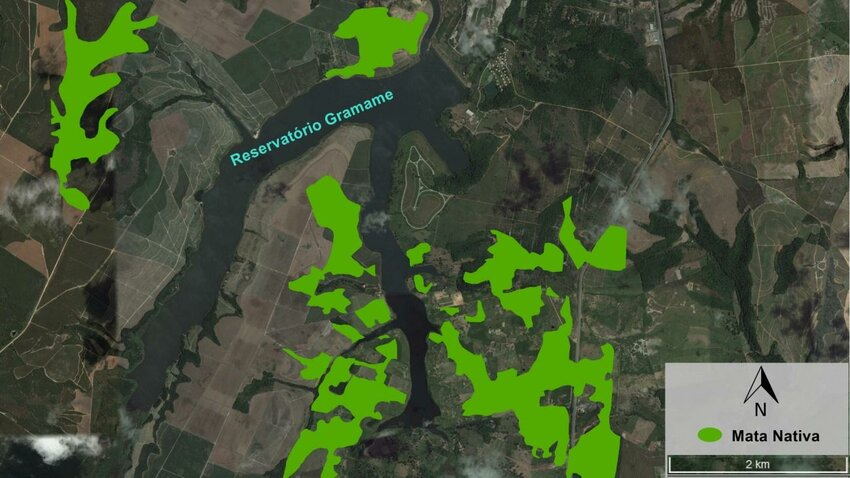

In [22]:
# Exibição do JPEG de referência geográfica
img_gramame_path = FIGURES_DIR / "gramame.jpeg"
if img_gramame_path.exists():
    display(Image(filename=str(img_gramame_path)))
else:
    print(f"Imagem de referência não encontrada em: {img_gramame_path}")

/home/carlos/Documentos/projetos/remote-sensing/venv/lib/python3.12/site-packages/matplotlib/cm.py:478: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


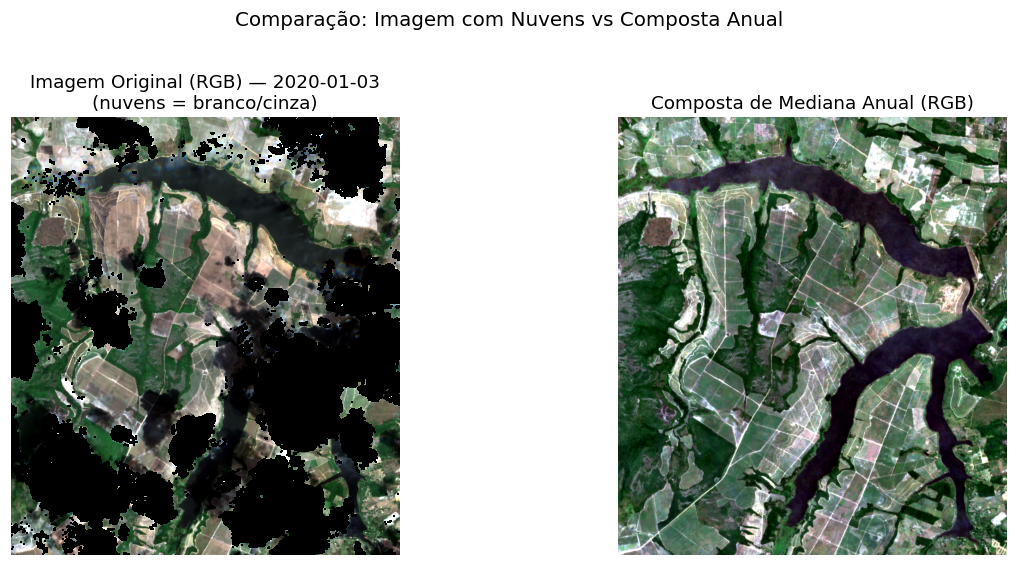

In [23]:
# Índice da data de exemplo para os painéis comparativos
idx_data_exemplo = 0
titulo_data = (
    datas[idx_data_exemplo].strftime("%Y-%m-%d")
    if datas[idx_data_exemplo] else f"data índice {idx_data_exemplo}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Imagem original — composição RGB com stretch
rgb_original = compor_rgb(stack[idx_data_exemplo])
axes[0].imshow(rgb_original)
axes[0].set_title(f"Imagem Original (RGB) — {titulo_data}\n(nuvens = branco/cinza)")
axes[0].axis("off")

# Composta de mediana anual — composição RGB com stretch
rgb_composite = compor_rgb(median_composite)
axes[1].imshow(rgb_composite)
axes[1].set_title("Composta de Mediana Anual (RGB)")
axes[1].axis("off")

plt.suptitle("Comparação: Imagem com Nuvens vs Composta Anual", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_original_vs_composite.png", bbox_inches="tight")
plt.show()

No painel à esquerda, a cena de janeiro de 2020 exibe extensas regiões sem dado
(brancas/cinzas), decorrentes da filtragem de nuvens e sombras. O painel à direita
exibe a composta de mediana anual (Método 1), preenchendo 100% da cena com o valor
típico de cada pixel ao longo do ano.

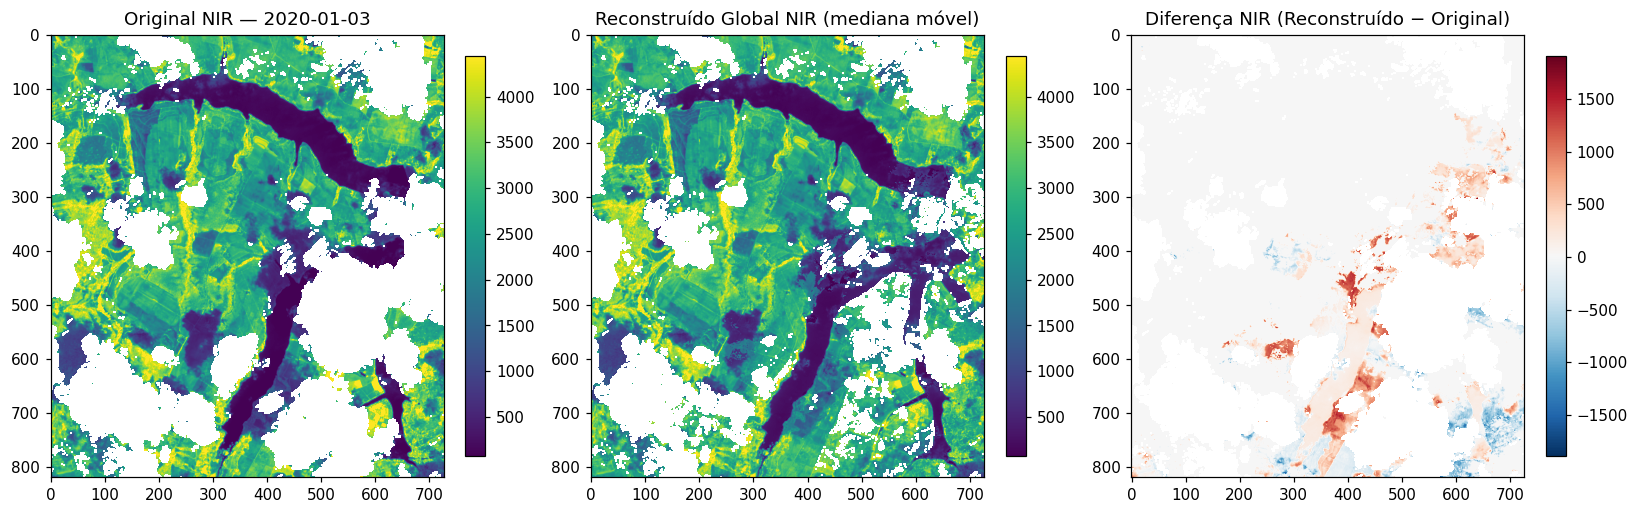

In [24]:
# Comparação visual do Método Global (banda NIR — maior contraste espectral)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanpercentile(stack[idx_data_exemplo, IDX_NIR], 2)
vmax = np.nanpercentile(stack[idx_data_exemplo, IDX_NIR], 98)

im0 = axes[0].imshow(stack[idx_data_exemplo, IDX_NIR], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Original NIR — {titulo_data}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(stack_reconstruido[idx_data_exemplo, IDX_NIR], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstruído Global NIR (mediana móvel)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diferenca_nir = stack_reconstruido[idx_data_exemplo, IDX_NIR] - stack[idx_data_exemplo, IDX_NIR]
im2 = axes[2].imshow(diferenca_nir, cmap="RdBu_r")
axes[2].set_title("Diferença NIR (Reconstruído − Original)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_original_vs_reconstruido_data.png")
plt.show()

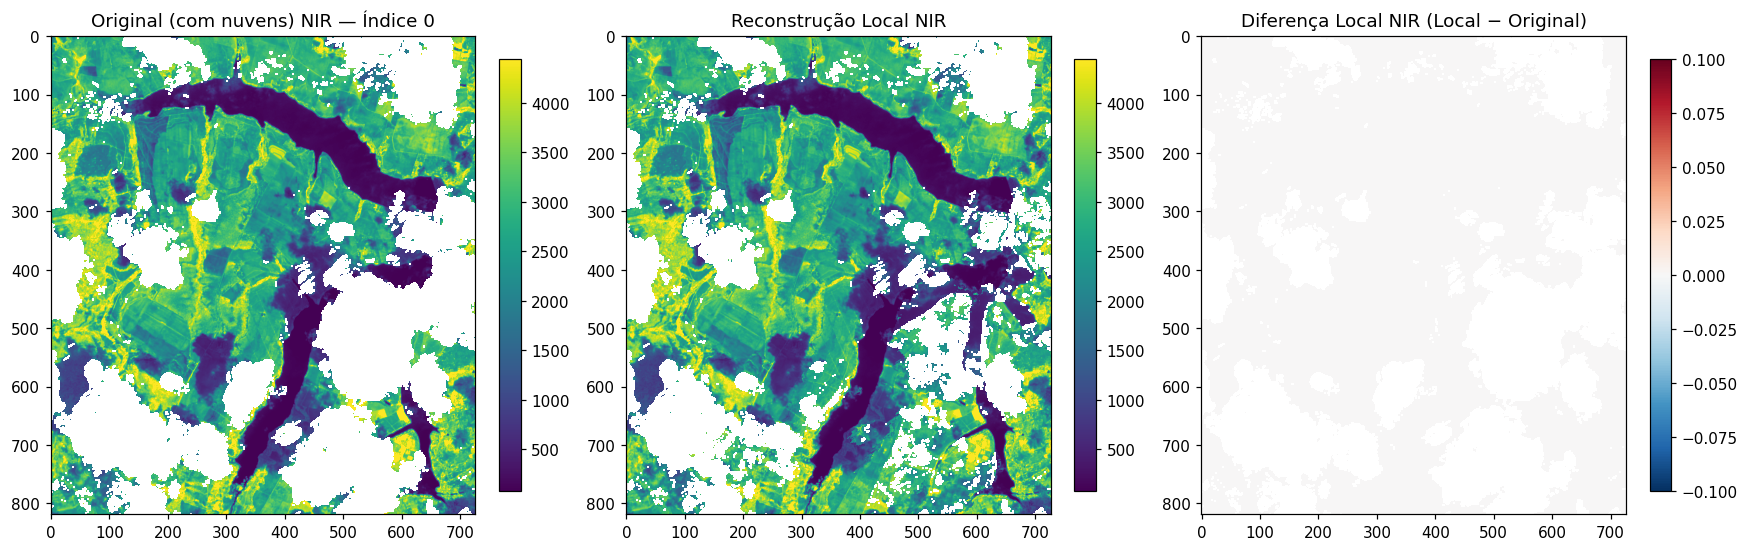

In [25]:
# Comparação visual do Método Local (banda NIR)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmin = np.nanpercentile(stack[idx_data_exemplo, IDX_NIR], 2)
vmax = np.nanpercentile(stack[idx_data_exemplo, IDX_NIR], 98)

im0 = axes[0].imshow(stack[idx_data_exemplo, IDX_NIR], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Original (com nuvens) NIR — Índice {idx_data_exemplo}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(stack_reconstruido_local[idx_data_exemplo, IDX_NIR], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstrução Local NIR")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diferenca_local_nir = stack_reconstruido_local[idx_data_exemplo, IDX_NIR] - stack[idx_data_exemplo, IDX_NIR]
im2 = axes[2].imshow(diferenca_local_nir, cmap="RdBu_r")
axes[2].set_title("Diferença Local NIR (Local − Original)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_espacial_metodo_local.png")
plt.show()

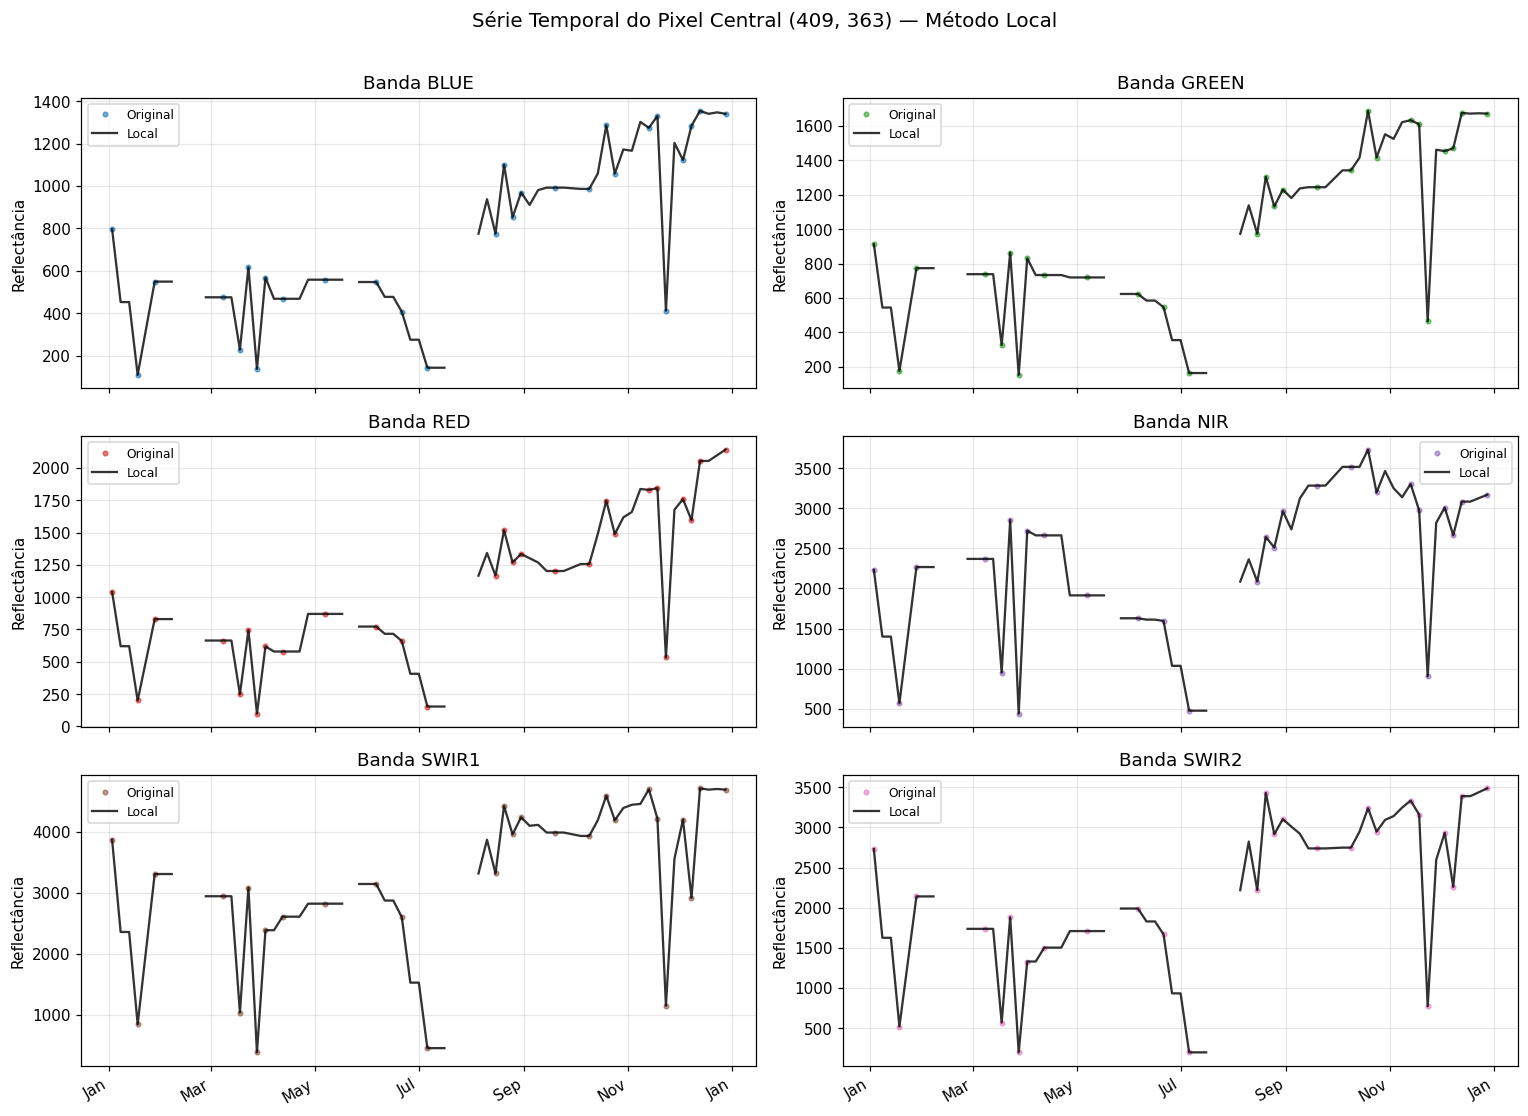

In [26]:
# Série temporal de pixel central — todas as 6 bandas em subplots
linha_pixel  = stack.shape[2] // 2
coluna_pixel = stack.shape[3] // 2
eixo_x = datas if all(d is not None for d in datas) else range(n_tempo)


fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for b, nome in enumerate(NOMES_BANDAS):
    ax = axes[b]
    cor = CORES_BANDAS.get(nome, "gray")

    serie_orig  = stack[:, b, linha_pixel, coluna_pixel]
    serie_recon = stack_reconstruido_local[:, b, linha_pixel, coluna_pixel]

    ax.plot(eixo_x, serie_orig,  "o",  color=cor,    alpha=0.6, markersize=3, label="Original")
    ax.plot(eixo_x, serie_recon, "-",  color="black", alpha=0.8, linewidth=1.5, label="Local")
    ax.set_title(f"Banda {nome.upper()}")
    ax.set_ylabel("Reflectância")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    if all(d is not None for d in datas):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.suptitle(
    f"Série Temporal do Pixel Central ({linha_pixel}, {coluna_pixel}) — Método Local",
    fontsize=13, y=1.01
)
if all(d is not None for d in datas):
    fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "serie_temporal_pixel_multibanda.png", bbox_inches="tight")
plt.show()

## 7. Validação Quantitativa com Métricas SSIM e PSNR

Validação por degradação sintética controlada. A imagem mais limpa da série é selecionada
como *Ground Truth*. Uma máscara sintética 2D (simulando perda de dado por nuvem) é
aplicada simultaneamente a **todas as 6 bandas** — correto fisicamente, pois uma nuvem
real bloqueia a cena inteira independentemente do canal espectral. Após a reconstrução,
as métricas SSIM e PSNR são calculadas por banda espectral.

### Validação Pontual: 15% de Corrupção Sintética (Método Local)

In [ ]:
# ─── Parâmetros da validação pontual ────────────────────────────────────────
SEED_VALIDACAO    = 26082002
taxa_corrupcao    = 0.15   # 15% da cena será corrompida sinteticamente

# 1. Identifica a imagem mais limpa da série (menor % de NaN)

pct_nan_por_data = np.isnan(stack[:, 0, :, :]).mean(axis=(1, 2))
idx_ref  = int(np.argmin(pct_nan_por_data))
img_ref  = stack[idx_ref].copy()   # shape (bandas, H, W)
data_str = datas[idx_ref].strftime('%Y-%m-%d') if datas[idx_ref] else f'Índice {idx_ref}'
print(f"Imagem de referência (Ground Truth): {data_str}  |  {100*pct_nan_por_data[idx_ref]:.1f}% NaN real")

# 2. Gera máscara sintética em blob conexo (fisicamente representativa de nuvem real)
#    A mesma máscara 2D é aplicada às 6 bandas simultaneamente — uma nuvem obstrui toda a cena
mascara_sintetica = gerar_mascara_nuvem_sintetica(
    shape=(altura, largura),
    taxa_corrupcao=taxa_corrupcao,
    seed=SEED_VALIDACAO,
)
print(f"Nuvem sintética (blob): {100*mascara_sintetica.mean():.1f}% da cena  "
      f"({mascara_sintetica.sum()} pixels corrompidos)")

# 3. Aplica corrupção a todas as bandas simultaneamente (broadcasting)
img_corrompida = img_ref.copy()
img_corrompida[:, mascara_sintetica] = np.nan   # (bandas, H, W)

# 4. Submete ao método local — apenas a janela temporal ao redor de idx_ref é processada
img_reconstruida = reconstruir_unica_data_multibanda(
    stack, idx_ref, JANELA_TEMPORAL, img_override=img_corrompida, nomes_bandas=NOMES_BANDAS
)  # shape (bandas, H, W)

# 5. Avalia apenas nos pixels efetivamente corrompidos
ref_para_avaliacao   = np.where(mascara_sintetica, img_ref,          np.nan)
teste_para_avaliacao = np.where(mascara_sintetica, img_reconstruida, np.nan)

# data_range fixo POR BANDA sobre a imagem de referência completa (para comparabilidade
# entre execuções, sem deixar a amplitude de uma banda distorcer o PSNR de outra)
data_range_fixo = calcular_data_range_por_banda(img_ref, nomes_bandas=NOMES_BANDAS)

metricas = calcular_metricas_multibanda(
    ref_para_avaliacao, teste_para_avaliacao,
    nomes_bandas=NOMES_BANDAS, data_range_fixo=data_range_fixo
)

print("\n" + "=" * 60)
print(f"{'VALIDAÇÃO QUANTITATIVA - MÉTODO LOCAL':^60}")
print("=" * 60)
print(f"Imagem Referência:  {data_str}")
print(f"Nuvem Sintética:    {100*mascara_sintetica.mean():.1f}% da cena  "
      f"({taxa_corrupcao*100:.0f}% alvo, blob conexo)")
print("-" * 60)
print(f"{'Banda':<8} {'SSIM':>10} {'PSNR (dB)':>12}")
print("-" * 60)
for nome in NOMES_BANDAS:
    d = metricas['detalhes_por_banda'][nome]
    print(f"{nome:<8} {d['ssim']:>10.4f} {d['psnr']:>12.2f}")
print("-" * 60)
print(f"{'Médio':<8} {metricas['ssim_medio']:>10.4f} {metricas['psnr_medio']:>12.2f}")
print("=" * 60)


Imagem de referência (Ground Truth): 2020-04-02  |  9.0% NaN real
Nuvem sintética (blob): 15.0% da cena  (89311 pixels corrompidos)

           VALIDAÇÃO QUANTITATIVA - MÉTODO LOCAL            
Imagem Referência:  2020-04-02
Nuvem Sintética:    15.0% da cena  (15% alvo, blob conexo)
------------------------------------------------------------
Banda          SSIM    PSNR (dB)
------------------------------------------------------------
blue         0.9761        28.17
green        0.9770        26.83
red          0.9731        25.66
nir          0.9736        21.39
swir1        0.9733        19.90
swir2        0.9695        19.59
------------------------------------------------------------
Médio        0.9738        23.59


### Validação Pontual Comparativa: Métodos 1, 2 e 3

In [28]:
print("=" * 70)
print("VALIDAÇÃO PONTUAL COMPARATIVA — MÉTODOS 1, 2 E 3 (mesma corrupção sintética)")
print("=" * 70)

taxa_corrupcao_comp = 0.15
idx_ref_comp = idx_ref  # reaproveita a mesma data de referência já definida
data_ref_comp = datas[idx_ref_comp]

seed_comp = 26082002
mascara_sint_comp = gerar_mascara_nuvem_sintetica(
    shape=(altura, largura), taxa_corrupcao=taxa_corrupcao_comp, seed=seed_comp
)

img_ref_comp = stack[idx_ref_comp].copy()          # (bandas, H, W) — ground truth real
img_corr_comp = img_ref_comp.copy()
img_corr_comp[:, mascara_sint_comp] = np.nan        # injeta a corrupção sintética

data_range_comp = calcular_data_range_por_banda(img_ref_comp, nomes_bandas=NOMES_BANDAS)

# --- Método 1: preenche os pixels corrompidos com a composta (recalculada sem vazamento) ---
composta_recomputada = recompor_composta_pontual_multibanda(
    stack, idx_ref_comp, mascara_sint_comp, median_composite, nomes_bandas=NOMES_BANDAS
)
img_m1 = img_corr_comp.copy()
img_m1[:, mascara_sint_comp] = composta_recomputada[:, mascara_sint_comp]

# --- Método 2: mediana móvel global (substitui todos os pixels da janela) ---
img_m2 = reconstruir_unica_data_global_multibanda(
    stack, idx_ref_comp, JANELA_TEMPORAL, img_override=img_corr_comp, nomes_bandas=NOMES_BANDAS
)

# --- Método 3: mediana móvel local (mesma função já usada nas células anteriores) ---
img_m3 = reconstruir_unica_data_multibanda(
    stack, idx_ref_comp, JANELA_TEMPORAL, img_override=img_corr_comp, nomes_bandas=NOMES_BANDAS
)

metodos = {
    "1 - Composta Anual": img_m1,
    "2 - Mediana Móvel Global": img_m2,
    "3 - Mediana Móvel Local": img_m3,
}

resultados_comp = []
for nome_metodo, img_metodo in metodos.items():
    # Avalia só os pixels efetivamente corrompidos — mesmo protocolo usado no Método 3
    ref_aval = np.where(mascara_sint_comp, img_ref_comp, np.nan)
    teste_aval = np.where(mascara_sint_comp, img_metodo, np.nan)

    m = calcular_metricas_multibanda(
        ref_aval, teste_aval, nomes_bandas=NOMES_BANDAS, data_range_fixo=data_range_comp
    )
    rmse_distorcao = calcular_rmse_distorcao_pixels_validos(
        img_ref_comp, img_metodo, mascara_sint_comp
    )
    resultados_comp.append({
        "metodo": nome_metodo,
        "ssim_medio": m["ssim_medio"],
        "psnr_medio": m["psnr_medio"],
        "nrmse_medio_pct": m["nrmse_medio_pct"],
        "rmse_distorcao_pixels_validos": rmse_distorcao,
    })

df_comparativo_metodos = pd.DataFrame(resultados_comp)
print(f"\nData de referência: {data_ref_comp}  |  Corrupção sintética: {taxa_corrupcao_comp*100:.0f}% ({mascara_sint_comp.sum()} pixels)\n")
print(df_comparativo_metodos.to_string(index=False))

VALIDAÇÃO PONTUAL COMPARATIVA — MÉTODOS 1, 2 E 3 (mesma corrupção sintética)

Data de referência: 2020-04-02 00:00:00  |  Corrupção sintética: 15% (89311 pixels)

                  metodo  ssim_medio  psnr_medio  nrmse_medio_pct  rmse_distorcao_pixels_validos
      1 - Composta Anual    0.978187   24.336707         6.405682                       0.000000
2 - Mediana Móvel Global    0.973771   23.588905         7.133192                     301.463811
 3 - Mediana Móvel Local    0.973771   23.588905         7.133192                       0.000000


### Curva de Degradação: SSIM e PSNR por Taxa de Corrupção (1% a 50%)

Analisa como a qualidade de reconstrução varia em função da taxa de corrupção sintética,
por banda espectral. É esperado que bandas como SWIR e NIR tenham comportamento diferente
das bandas visíveis (blue, green, red) pelas suas características de reflectância físicas
distintas.

In [29]:
# data_range fixo POR BANDA — mantido constante em todas as iterações (sem saltos de
# platô) e sem deixar a amplitude de uma banda distorcer o PSNR de outra
data_range_fixo = calcular_data_range_por_banda(img_ref, nomes_bandas=NOMES_BANDAS)

taxas_corrupcao = np.arange(0.01, 0.51, 0.01)   # 1% até 50%, passo de 1%
resultados = []

print(f"Executando curva de degradação ({len(taxas_corrupcao)} iterações com blob conexo)...")

for taxa in taxas_corrupcao:
    seed_iter = int(26082002 + round(taxa * 1000))
    mascara_sint = gerar_mascara_nuvem_sintetica(
        shape=(altura, largura),
        taxa_corrupcao=taxa,
        seed=seed_iter,
    )

    img_corr = img_ref.copy()
    img_corr[:, mascara_sint] = np.nan

    # Reconstrói SÓ a data idx_ref, olhando só a janela temporal ao redor dela —
    # evita copiar/reconstruir o stack inteiro (73 datas × 6 bandas) por iteração
    img_recon = reconstruir_unica_data_multibanda(
        stack, idx_ref, JANELA_TEMPORAL, img_override=img_corr, nomes_bandas=NOMES_BANDAS
    )

    ref_aval   = np.where(mascara_sint, img_ref,   np.nan)
    teste_aval = np.where(mascara_sint, img_recon, np.nan)

    metricas = calcular_metricas_multibanda(
        ref_aval, teste_aval,
        nomes_bandas=NOMES_BANDAS,
        data_range_fixo=data_range_fixo,
    )

    linha = {"taxa_corrupcao_pct": round(taxa * 100, 1)}
    for nome in NOMES_BANDAS:
        d = metricas["detalhes_por_banda"][nome]
        linha[f"ssim_{nome}"] = d["ssim"]
        linha[f"psnr_{nome}"] = d["psnr"]
        linha[f"nrmse_{nome}"] = d["nrmse_pct"]
    linha["ssim_medio"] = metricas["ssim_medio"]
    linha["psnr_medio"] = metricas["psnr_medio"]
    linha["nrmse_medio"] = metricas["nrmse_medio_pct"]
    linha["n_pixels_corrompidos"] = int(mascara_sint.sum())
    resultados.append(linha)

df_validacao_corrupcao = pd.DataFrame(resultados)
print("Curva de degradação concluída.")
df_validacao_corrupcao.head(10)

Executando curva de degradação (50 iterações com blob conexo)...
Curva de degradação concluída.


,taxa_corrupcao_pct,ssim_blue,psnr_blue,nrmse_blue,ssim_green,psnr_green,nrmse_green,ssim_red,psnr_red,nrmse_red,...,ssim_swir1,psnr_swir1,nrmse_swir1,ssim_swir2,psnr_swir2,nrmse_swir2,ssim_medio,psnr_medio,nrmse_medio,n_pixels_corrompidos
0,1.0,0.998172,26.353270,4.812121,0.998594,26.023571,4.998290,0.998261,24.207377,6.160715,...,0.998819,18.917034,11.327870,0.998308,17.858852,12.795505,0.998537,22.501074,8.061314,5954
1,2.0,0.996829,27.550852,4.192349,0.997181,26.516428,4.722573,0.996322,25.558356,5.273297,...,0.996879,20.191081,9.782411,0.996467,21.919963,8.016815,0.996796,23.737629,6.870792,11908
2,3.0,0.995608,29.541016,3.333874,0.995931,27.959770,3.999553,0.994975,26.858756,4.540066,...,0.995472,21.102324,8.808132,0.994866,22.419094,7.569118,0.995432,24.851245,6.155640,17862
3,4.0,0.994429,28.165362,3.905997,0.995078,26.576701,4.689915,0.993801,25.653637,5.215767,...,0.994575,19.060606,11.142168,0.993214,19.887550,10.130305,0.994382,23.193532,7.549446,23816
4,5.0,0.992126,28.227047,3.878356,0.991446,25.952977,5.039079,0.990603,25.339154,5.408070,...,0.989579,19.388856,10.728949,0.989561,20.668694,9.259026,0.990615,23.255791,7.393655,29770
5,6.0,0.987695,26.885957,4.525871,0.986994,25.180541,5.507734,0.986151,24.167228,6.189258,...,0.983303,17.628301,13.139685,0.982527,18.559254,11.804220,0.984967,21.906609,8.727207,35724
6,7.0,0.986730,27.311852,4.309306,0.987307,25.594004,5.251699,0.985237,24.878743,5.702468,...,0.986011,18.013118,12.570255,0.983983,18.958480,11.273947,0.985912,22.139250,8.597085,41678
7,8.0,0.987076,29.471519,3.360656,0.986438,28.115364,3.928545,0.984836,26.658705,4.645845,...,0.981172,19.292896,10.848137,0.979808,18.276236,12.195179,0.983591,23.954266,7.167261,47633
8,9.0,0.983808,27.825192,4.062004,0.982566,25.689612,5.194208,0.980620,25.217468,5.484368,...,0.977840,18.596331,11.753939,0.977853,20.136546,9.844025,0.980044,22.550960,8.193491,53587
9,10.0,0.982778,28.866031,3.603283,0.982390,27.395691,4.267912,0.980472,26.257518,4.865462,...,0.976948,19.697383,10.354541,0.975869,20.128508,9.853139,0.979241,23.914627,6.951948,59541


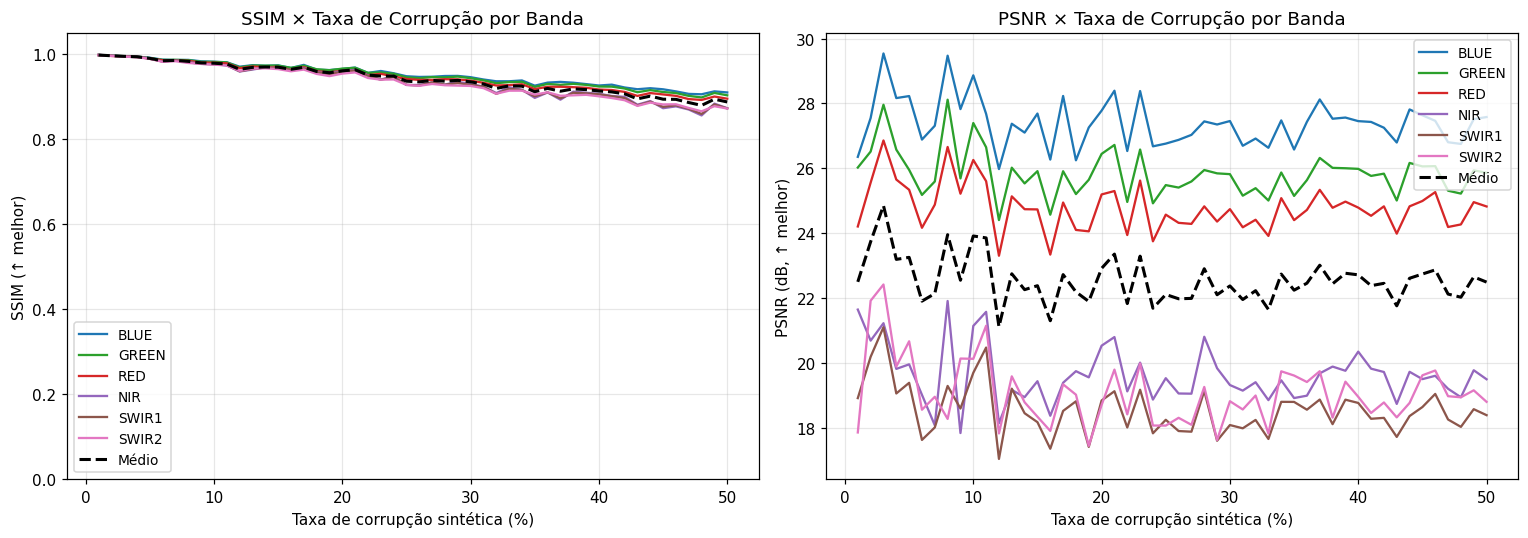

In [30]:

# Plots das curvas SSIM e PSNR por banda

x = df_validacao_corrupcao["taxa_corrupcao_pct"]

fig, (ax_ssim, ax_psnr) = plt.subplots(1, 2, figsize=(14, 5))

for nome in NOMES_BANDAS:
    cor = CORES_BANDAS[nome]
    ax_ssim.plot(x, df_validacao_corrupcao[f"ssim_{nome}"], color=cor, label=nome.upper(), linewidth=1.5)
    ax_psnr.plot(x, df_validacao_corrupcao[f"psnr_{nome}"], color=cor, label=nome.upper(), linewidth=1.5)

# Linhas da média
ax_ssim.plot(x, df_validacao_corrupcao["ssim_medio"], color="black", linestyle="--", linewidth=2, label="Médio")
ax_psnr.plot(x, df_validacao_corrupcao["psnr_medio"], color="black", linestyle="--", linewidth=2, label="Médio")

ax_ssim.set_title("SSIM × Taxa de Corrupção por Banda")
ax_ssim.set_xlabel("Taxa de corrupção sintética (%)")
ax_ssim.set_ylabel("SSIM (↑ melhor)")
ax_ssim.legend(fontsize=9)
ax_ssim.grid(alpha=0.3)
ax_ssim.set_ylim([0, 1.05])

ax_psnr.set_title("PSNR × Taxa de Corrupção por Banda")
ax_psnr.set_xlabel("Taxa de corrupção sintética (%)")
ax_psnr.set_ylabel("PSNR (dB, ↑ melhor)")
ax_psnr.legend(fontsize=9)
ax_psnr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curva_degradacao_multibanda.png")
plt.show()



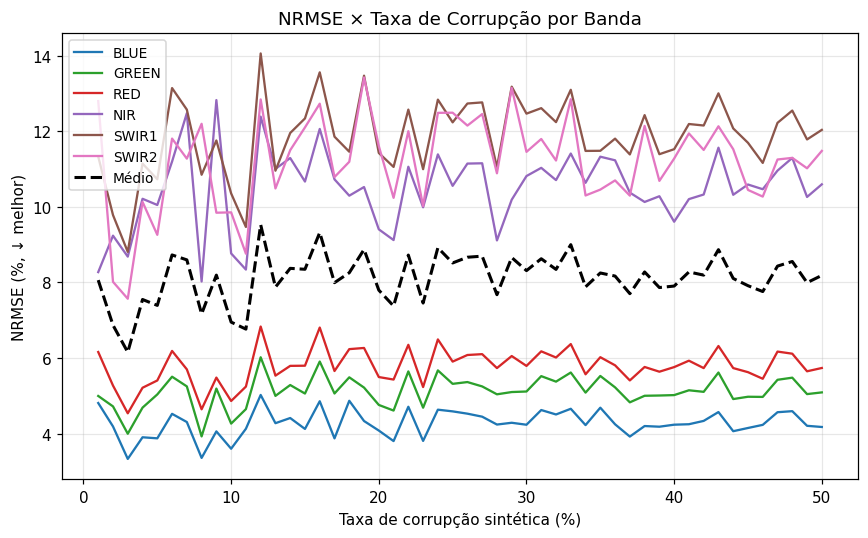

In [31]:
# Plot do NRMSE (%) por banda — comparável diretamente entre bandas de escalas físicas
# diferentes, ao contrário do PSNR (que depende do data_range absoluto de cada banda)
fig, ax = plt.subplots(figsize=(8, 5))

for nome in NOMES_BANDAS:
    cor = CORES_BANDAS[nome]
    ax.plot(x, df_validacao_corrupcao[f"nrmse_{nome}"], color=cor, label=nome.upper(), linewidth=1.5)

ax.plot(x, df_validacao_corrupcao["nrmse_medio"], color="black", linestyle="--", linewidth=2, label="Médio")

ax.set_title("NRMSE × Taxa de Corrupção por Banda")
ax.set_xlabel("Taxa de corrupção sintética (%)")
ax.set_ylabel("NRMSE (%, ↓ melhor)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nrmse_degradacao_multibanda.png")
plt.show()

In [32]:
data_range_fixo_curva = calcular_data_range_por_banda(img_ref, nomes_bandas=NOMES_BANDAS)

taxas_corrupcao = np.arange(0.01, 0.51, 0.01)
resultados_curva_comp = []

print(f"Executando curva de degradação comparativa (3 métodos × {len(taxas_corrupcao)} taxas)...")

for taxa in taxas_corrupcao:
    seed_iter = int(26082002 + round(taxa * 1000))
    mascara_sint = gerar_mascara_nuvem_sintetica(
        shape=(altura, largura), taxa_corrupcao=taxa, seed=seed_iter
    )

    img_corr = img_ref.copy()
    img_corr[:, mascara_sint] = np.nan

    composta_recomputada = recompor_composta_pontual_multibanda(
        stack, idx_ref, mascara_sint, median_composite, nomes_bandas=NOMES_BANDAS
    )
    img_m1 = img_corr.copy()
    img_m1[:, mascara_sint] = composta_recomputada[:, mascara_sint]

    img_m2 = reconstruir_unica_data_global_multibanda(
        stack, idx_ref, JANELA_TEMPORAL, img_override=img_corr, nomes_bandas=NOMES_BANDAS
    )

    img_m3 = reconstruir_unica_data_multibanda(
        stack, idx_ref, JANELA_TEMPORAL, img_override=img_corr, nomes_bandas=NOMES_BANDAS
    )

    for nome_metodo, img_metodo in [("composta", img_m1), ("global", img_m2), ("local", img_m3)]:
        ref_aval = np.where(mascara_sint, img_ref, np.nan)
        teste_aval = np.where(mascara_sint, img_metodo, np.nan)
        m = calcular_metricas_multibanda(
            ref_aval, teste_aval, nomes_bandas=NOMES_BANDAS, data_range_fixo=data_range_fixo_curva
        )
        rmse_distorcao = calcular_rmse_distorcao_pixels_validos(
            img_ref, img_metodo, mascara_sint
        )
        resultados_curva_comp.append({
            "taxa_corrupcao_pct": round(taxa * 100, 1),
            "metodo": nome_metodo,
            "ssim_medio": m["ssim_medio"],
            "psnr_medio": m["psnr_medio"],
            "nrmse_medio_pct": m["nrmse_medio_pct"],
            "rmse_distorcao_pixels_validos": rmse_distorcao,
        })

df_curva_comparativa = pd.DataFrame(resultados_curva_comp)
print("Curva de degradação comparativa concluída.")
df_curva_comparativa.head(9)

Executando curva de degradação comparativa (3 métodos × 50 taxas)...
Curva de degradação comparativa concluída.


,taxa_corrupcao_pct,metodo,ssim_medio,psnr_medio,nrmse_medio_pct,rmse_distorcao_pixels_validos
0,1.0,composta,0.998491,22.450956,8.288681,0.000000
1,1.0,global,0.998537,22.501074,8.061314,295.305547
2,1.0,local,0.998537,22.501074,8.061314,0.000000
3,2.0,composta,0.997648,24.454760,6.399319,0.000000
4,2.0,global,0.996796,23.737629,6.870792,295.450353
5,2.0,local,0.996796,23.737629,6.870792,0.000000
6,3.0,composta,0.997335,26.853657,4.921767,0.000000
7,3.0,global,0.995432,24.851245,6.155640,297.797274
8,3.0,local,0.995432,24.851245,6.155640,0.000000


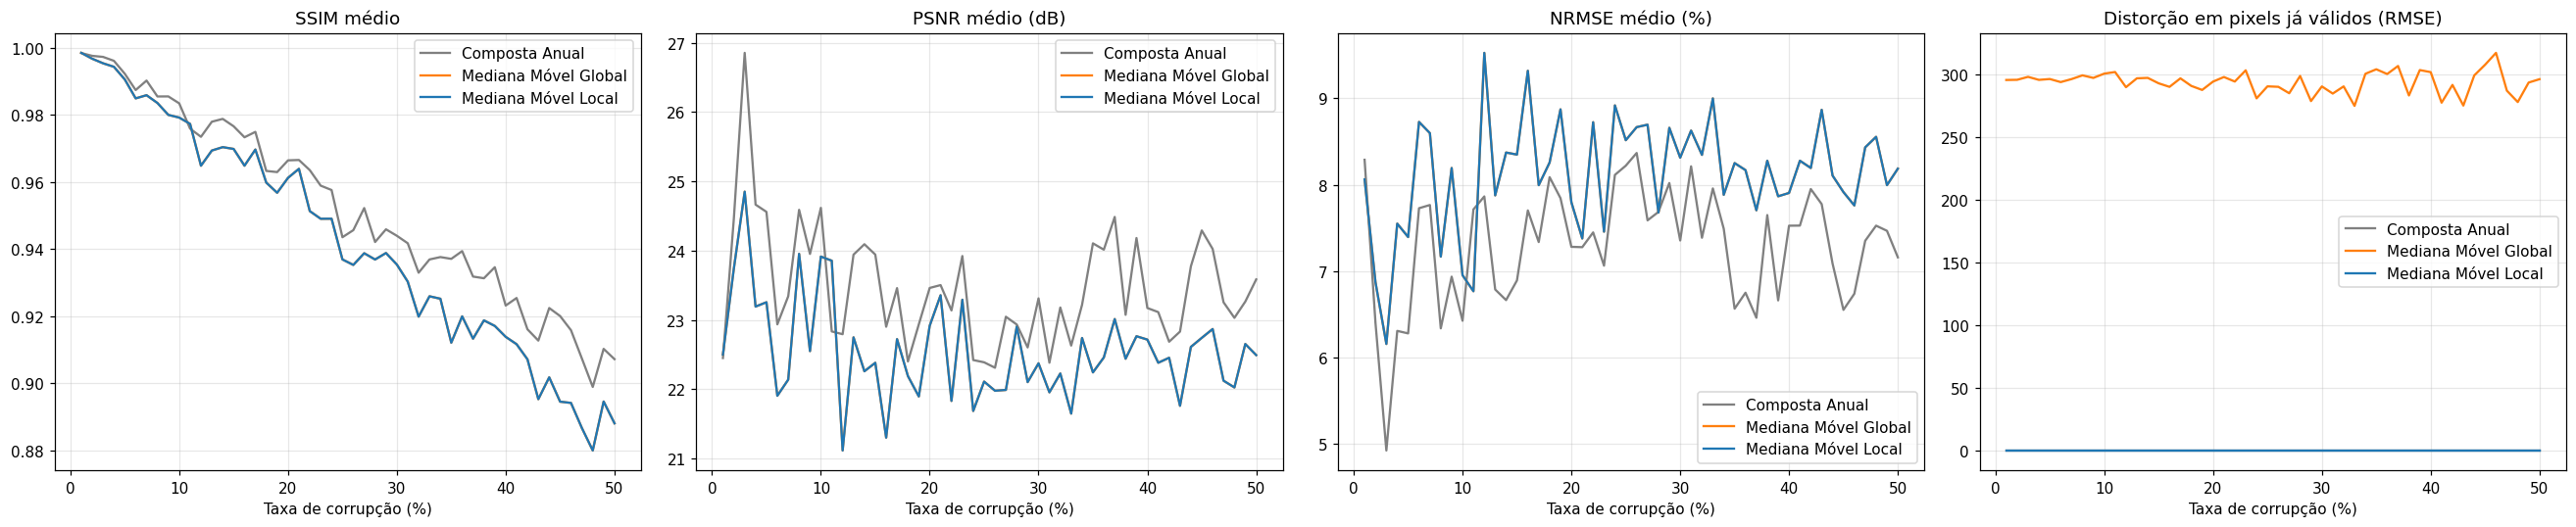

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
cores_metodo = {"composta": "gray", "global": "tab:orange", "local": "tab:blue"}
rotulos_metodo = {"composta": "Composta Anual", "global": "Mediana Móvel Global", "local": "Mediana Móvel Local"}

for metodo, cor in cores_metodo.items():
    sub = df_curva_comparativa[df_curva_comparativa["metodo"] == metodo]
    axes[0].plot(sub["taxa_corrupcao_pct"], sub["ssim_medio"], color=cor, label=rotulos_metodo[metodo])
    axes[1].plot(sub["taxa_corrupcao_pct"], sub["psnr_medio"], color=cor, label=rotulos_metodo[metodo])
    axes[2].plot(sub["taxa_corrupcao_pct"], sub["nrmse_medio_pct"], color=cor, label=rotulos_metodo[metodo])
    axes[3].plot(sub["taxa_corrupcao_pct"], sub["rmse_distorcao_pixels_validos"], color=cor, label=rotulos_metodo[metodo])

axes[0].set_title("SSIM médio"); axes[0].set_xlabel("Taxa de corrupção (%)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("PSNR médio (dB)"); axes[1].set_xlabel("Taxa de corrupção (%)"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].set_title("NRMSE médio (%)"); axes[2].set_xlabel("Taxa de corrupção (%)"); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[3].set_title("Distorção em pixels já válidos (RMSE)"); axes[3].set_xlabel("Taxa de corrupção (%)"); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparativo_3_metodos.png")
plt.show()